---
This file is to be used and edited for the audio problems done in PH364
(If a cell does not display a graph, use plt.close('all'))

---

In [1]:
#Importing modules
from matplotlib.widgets import RangeSlider
import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.io import wavfile
from pathlib import Path
import numpy as np
import scipy

#The following code finds the .wav files in any personal Jupyter Notebook
repos_dir = Path.cwd()

banjo_file = repos_dir / 'data' / 'banjo-mono.wav'
guitar_file = repos_dir / 'data' / 'guitar-mono.wav'

#Defining all variables
banjo_samplerate, banjo_data = wavfile.read(banjo_file)
banjo_period = banjo_data.size/banjo_samplerate
banjo_time = np.arange(0,banjo_data.size,1)/banjo_samplerate
banjo = Audio(banjo_data,rate = banjo_samplerate)

guitar_samplerate, guitar_data = wavfile.read(guitar_file)
guitar_period = guitar_data.size/guitar_samplerate
guitar_time = np.arange(0,guitar_data.size,1)/guitar_samplerate
guitar = Audio(guitar_data,rate = guitar_samplerate)

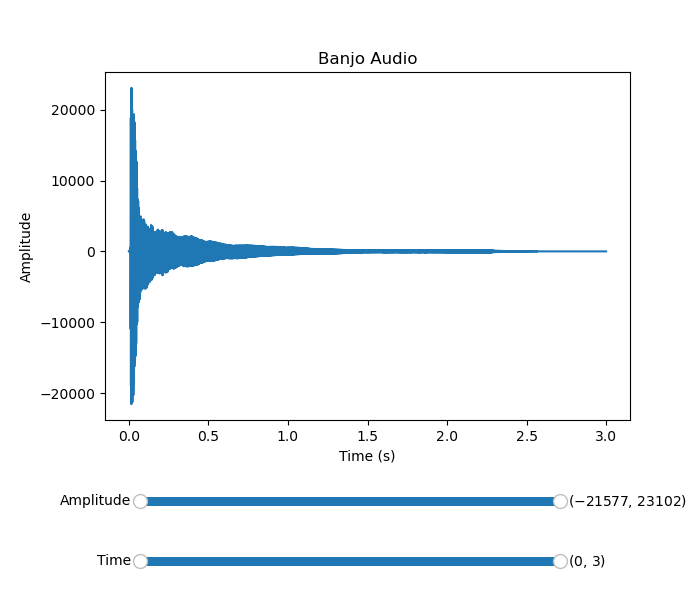

In [10]:
#The following code outputs an audio files amplitude vs time with sliders to see how the audio changes over time in higher detail

#Makes the notebook use widgets, which allows all plots to be interactable
%matplotlib widget
plt.close('all')

#Creates the audio subplot with labels
fig_banjo, ax_banjo = plt.subplots(figsize=(7,6))
plt.subplots_adjust(bottom=0.3,left=0.15)
ax_banjo.plot(banjo_time,banjo_data)
ax_banjo.set( 
    xlabel='Time (s)',
    ylabel='Amplitude',
    title='Banjo Audio'
)

#Adds the time axis slider between the minimum and maximum time values
ax_timeb = plt.axes([0.20, 0.05, 0.60, 0.03])
slider_timeb = RangeSlider(
    ax_timeb, "Time",
    banjo_time.min(), banjo_time.max(),
    valinit=(banjo_time.min(), banjo_time.max())
)

#Adds the amplitude axis slider between the minimum and maximum amplitude values
ax_ampb = plt.axes([0.20, 0.15, 0.60, 0.03])
slider_ampb = RangeSlider(
    ax_ampb, "Amplitude",
    banjo_data.min(), banjo_data.max(),
    valinit=(banjo_data.min(), banjo_data.max())
)

#Creates a function to use matplotlib widgets to update the graph when interacted with
def update(val):
    ax_banjo.set_xlim(slider_timeb.val)
    ax_banjo.set_ylim(slider_ampb.val)
    fig_banjo.canvas.draw_idle()

slider_timeb.on_changed(update)
slider_ampb.on_changed(update)

plt.show()
display(banjo)
#Sets the notebook back to inline so that new plots do not get interfered with
%matplotlib inline

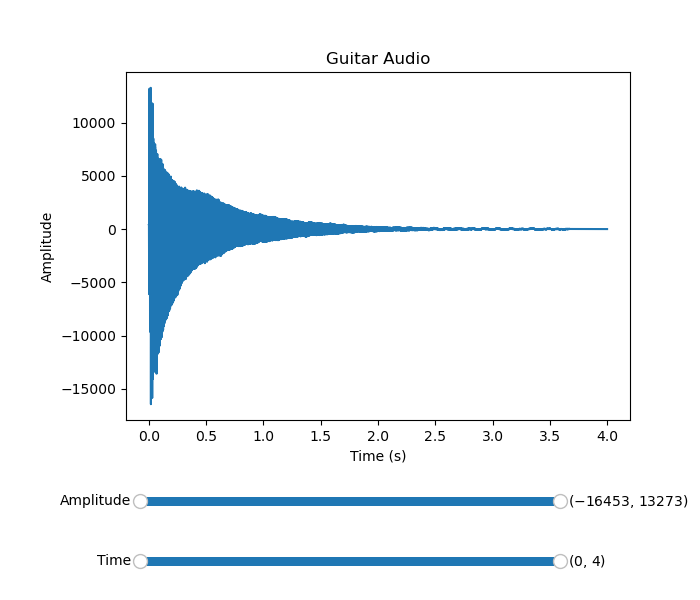

In [8]:
#This cell does the same thing as the previous, but for the guitar audio file
%matplotlib widget
plt.close('all')

fig_guitar, ax_guitar = plt.subplots(figsize=(7,6))
plt.subplots_adjust(bottom=0.3,left=0.18)
ax_guitar.plot(guitar_time,guitar_data)
ax_guitar.set( 
    xlabel='Time (s)',
    ylabel='Amplitude',
    title='Guitar Audio'
)

ax_timeg = plt.axes([0.20, 0.05, 0.60, 0.03])
slider_timeg = RangeSlider(
    ax_timeg, "Time",
    guitar_time.min(), guitar_time.max(),
    valinit=(guitar_time.min(), guitar_time.max())
)

ax_ampg = plt.axes([0.20, 0.15, 0.60, 0.03])
slider_ampg = RangeSlider(
    ax_ampg, "Amplitude",
    guitar_data.min(), guitar_data.max(),
    valinit=(guitar_data.min(), guitar_data.max())
)


def update(val):
    ax_guitar.set_xlim(slider_timeg.val)
    ax_guitar.set_ylim(slider_ampg.val)
    fig_guitar.canvas.draw_idle()

slider_timeg.on_changed(update)
slider_ampg.on_changed(update)

plt.show()
display(guitar)
%matplotlib inline

In [9]:
plt.close('all') #Closes all plots to reduce lag

---
## Current Questions:

- What frequencies are the instrument plucks composed of and how do they differ? [Fourier Series]

- How does the damping coefficient of the simple harmonic oscillations made by the guitar and the banjo differ?

- Can we reconstruct a SHOE of a pluck for both instruments based on the audio data provided?

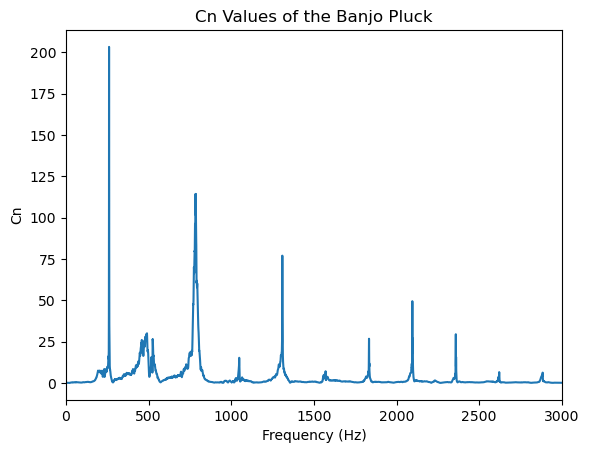

In [2]:
#Performs the fast fourier transform to calculate the Cn values of the audio file
cn_banjo = scipy.fft.fft(banjo_data)
Nb = np.arange(0,banjo_data.size)

#Plots the Cn values along frequency
plt.plot(Nb/banjo_period, np.real(abs(cn_banjo))/banjo_data.size);
plt.xlabel('Frequency (Hz)')
plt.ylabel('Cn')
plt.title('Cn Values of the Banjo Pluck')
plt.axis(xmax=3000, xmin=0);

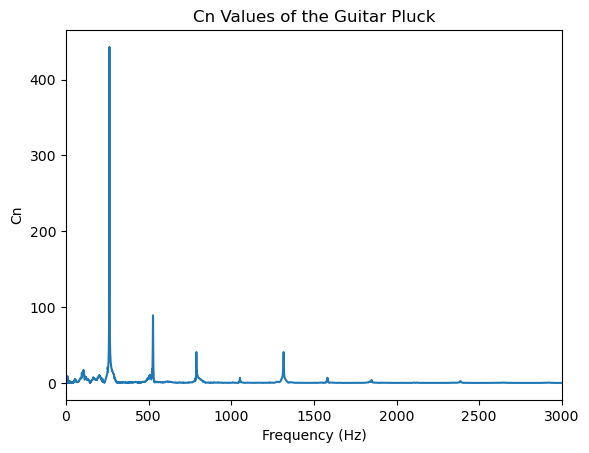

In [6]:
cn_guitar = scipy.fft.fft(guitar_data)
Ng = np.arange(0,guitar_data.size)

plt.plot(Ng/guitar_period, np.real(abs(cn_guitar))/guitar_data.size);
plt.title('Cn Values of the Guitar Pluck')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Cn')
plt.axis(xmax=3000, xmin=0);

Interestingly, the large amplitude waves seem to occur within the the audio of the pluck at a regular interval of frequencies for both the guitar and the banjo. The most influential wave has a frequency of ~260 for both instruments, and has reoccuring spikes at a similar interval. However, the ampltiude and clearity of the spikes changes between the two. This leads me to believe that the pattern of the frequencies might be related to the 12th root of 2 pattern that western music folows, while the magnitude of Cn at different frequencies is determines by the acoustic properties of the instrument.

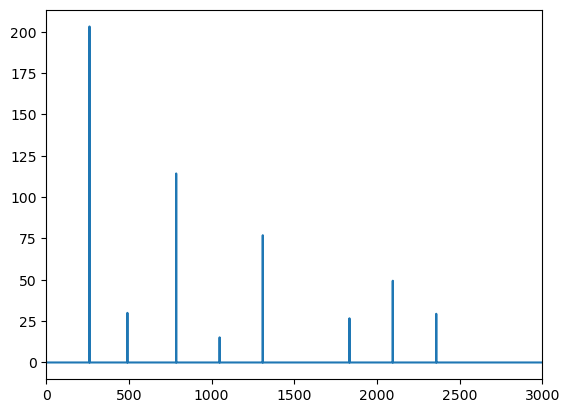

In [9]:
from scipy.signal import find_peaks

banjo_main, banjo_height = find_peaks((np.real(abs(cn_banjo))/banjo_data.size), height = 15,distance = 150)

new_banjo = np.zeros(Nb.size)

for i in range(Nb.size):
    if i in banjo_main:
        new_banjo[i] = np.real(abs(cn_banjo[i]))/banjo_data.size

plt.plot(Nb/banjo_period,new_banjo)
plt.axis(xmax=3000, xmin=0);
#Do an inverse fft where every array indices we dont care about is 0, and all indices we care about are found by find_peaks

banjo_reconstruct = scipy.fft.ifft(new_banjo)
banjo_new_wav = Audio(banjo_reconstruct,rate = banjo_samplerate)
display(banjo_new_wav)

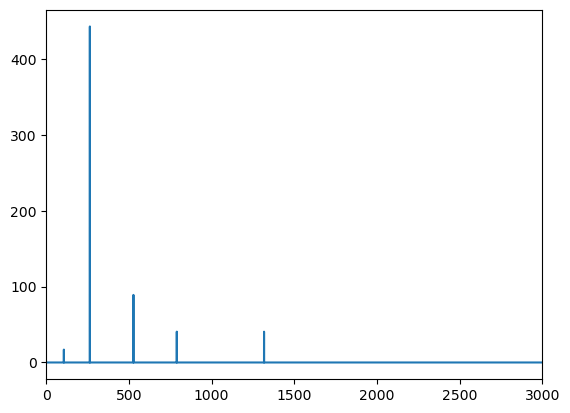

In [10]:
from scipy.signal import find_peaks

guitar_main, guitar_height = find_peaks((np.real(abs(cn_guitar))/guitar_data.size), height = 15,distance = 150)

new_guitar = np.zeros(Ng.size)

for i in range(Ng.size):
    if i in guitar_main:
        new_guitar[i] = np.real(abs(cn_guitar[i]))/guitar_data.size

plt.plot(Ng/guitar_period,new_guitar)
plt.axis(xmax=3000, xmin=0);
#Do an inverse fft where every array indices we dont care about is 0, and all indices we care about are found by find_peaks

guitar_reconstruct = scipy.fft.ifft(new_guitar)
guitar_new_wav = Audio(guitar_reconstruct,rate = guitar_samplerate)
display(guitar_new_wav)